In [10]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import glob

In [11]:
from lobster import *

In [12]:
ticker = "INTC"
date = "2012-06-21"
folder1 = "data"
folder2 = "LOBSTER_SampleFile_INTC_2012-06-21_5"
code = "34200000_57600000"
message_path = f"{folder1}/{folder2}/{ticker}_{date}_{code}_message_5.csv"
orderbook_path = f"{folder1}/{folder2}/{ticker}_{date}_{code}_orderbook_5.csv"

levels = 5
K = 5

msg, ob, qr, df = load_lobster_data(
    message_path,
    orderbook_path,
    levels=levels,
    K=K
)

df

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,100,275150.0,275200.0,166,...,200,275500.0,0,274800.0,661,275600.0,100,274700.0,300,1
1,34200.006462,0.000221,0.000221,L,275500,4,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
2,34200.048864,0.042402,0.042623,C,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
3,34200.048883,0.000020,0.042642,C,275100,-1,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
4,34200.048989,0.000106,0.000125,L,275000,-2,100,275150.0,275200.0,166,...,200,275500.0,100,274800.0,661,275600.0,100,274700.0,300,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580346,57599.860444,0.011408,0.011408,C,267200,1,34600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580347,57599.860635,0.000191,0.223738,L,267000,-2,16600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580348,57599.870108,0.009473,0.249387,C,267400,3,600,267150.0,267200.0,88104,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157
580349,57599.939645,0.069536,0.079201,L,267200,1,100,267150.0,267200.0,88204,...,28495,267500.0,59278,266800.0,46883,267600.0,60383,266700.0,58174,1157


In [13]:
table1 = make_descriptive_table(df, K=5)
table1

,#L (×10^3),#C (×10^3),#M (×10^2),AES,AIT (ms)
Level,,,,,
1,197.19,162.42,324.82,483.88,119.1
2,40.20,59.75,0.00,441.55,462.3
3,22.71,22.55,0.00,451.23,1004.4
4,13.23,11.88,0.00,475.07,1672.0
5,9.50,8.44,0.00,596.93,2263.0


In [14]:
aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size") 
df_norm = normalize_by_aes(df, aes=aes, K=5)
df_norm.head(10)

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
5,34200.049011,0.000022,0.042770,L,274900,-3,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
6,34200.049078,0.000068,0.042837,L,274800,-4,2,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,1,1
7,34200.049110,0.000032,0.042869,L,274700,-5,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
8,34200.049301,0.000190,0.000311,L,275000,-2,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1
9,34200.211338,0.162038,0.205097,M,275200,1,1,275150.0,275200.0,1,...,2,275500.0,1,274800.0,3,275600.0,1,274700.0,2,1


In [15]:
print("Average Limit Size", df_norm[(df_norm["type"]=="L") & (abs(df_norm["lvl"])==1)]["size"].mean())
print("Average Cancel Size", df_norm[(df_norm["type"]=="C") & (abs(df_norm["lvl"])==1)]["size"].mean())
print("Average Market Size", df_norm[(df_norm["type"]=="M") & (abs(df_norm["lvl"])==1)]["size"].mean())

Average Limit Size 1.6776068237370305
Average Cancel Size 1.6462852252507403
Average Market Size 1.3429283911089218


In [16]:
df_norm.describe().loc["max"]

time      57599.948442
dtk           6.972331
dtk_l        97.090885
price         276300.0
lvl                5.0
size             171.0
pref          275950.0
P_1           276000.0
Q_1              322.0
P_-1          275900.0
Q_-1             312.0
P_2           276100.0
Q_2              398.0
P_-2          275800.0
Q_-2             341.0
P_3           276200.0
Q_3              246.0
P_-3          275700.0
Q_-3             168.0
P_4           276300.0
Q_4              160.0
P_-4          275600.0
Q_-4             156.0
P_5           276400.0
Q_5              117.0
P_-5          275500.0
Q_-5             124.0
seg_id          1157.0
Name: max, dtype: Float64

### Training DataFrame: ###
From where we will extract our different state vectors $x_k$.

In [17]:
df_train = df_norm.copy()

def build_training_dfs_by_level(df_train):
    event_map = {"L": 0, "C": 1, "M": 2}
    out = {}

    for lvl, df in df_train.groupby("lvl"):
        df = df.copy()

        # 1) Event ID
        df["event_id"] = df["type"].map(event_map)

        # 2) Hour of last event
        df["hour_last_event"] = df["time"].shift(1) // 3600

        # 3) Last event ID
        df["last_event_id"] = df["event_id"].shift(1)

        # 4) Queue before event
        df["q"] = df[f"Q_{lvl}"].shift(1)

        # Formatting
        df = df.dropna().reset_index(drop=True)
        df["hour_last_event"] = df["hour_last_event"].astype("int64")
        hour_map = {h: i for i, h in enumerate(sorted(df["hour_last_event"].unique()))}
        df["hour_last_event"] = df["hour_last_event"].map(hour_map)
        df["last_event_id"] = df["last_event_id"].astype("int64")
        df["q"] = df["q"].astype("int64")

        out[lvl] = df[["event_id", "dtk_l", "q", "hour_last_event", "last_event_id"]]

    return out

def build_training_dfs_by_abs_level(df_train):
    dfs_by_level = build_training_dfs_by_level(df_train)
    dfs_by_abs_level = {}

    abs_levels = sorted({abs(lvl) for lvl in dfs_by_level.keys()})

    for k in abs_levels:
        parts = []
        if -k in dfs_by_level:
            parts.append(dfs_by_level[-k].copy())
        if k in dfs_by_level:
            parts.append(dfs_by_level[k].copy())

        if parts:
            dfs_by_abs_level[k] = pd.concat(parts, ignore_index=True)

    return dfs_by_abs_level

In [18]:
dfs_by_abs_level = build_training_dfs_by_abs_level(df_train)
print(dfs_by_abs_level.keys())

dict_keys([1, 2, 3, 4, 5])


In [19]:
dfs_by_abs_level[1]

,event_id,dtk_l,q,hour_last_event,last_event_id
0,0,0.162572,1,0,1
1,0,0.000007,2,0,0
2,0,0.000002,2,0,0
3,1,0.000094,2,0,0
4,0,0.000000,2,0,1
...,...,...,...,...,...
392088,1,0.010125,256,6,1
392089,1,0.206373,253,6,1
392090,0,0.014818,252,6,1
392091,1,0.011408,254,6,0


### QR Model Intensities ###

In [20]:
from qrFunctions import shift_orderbook_before_event, build_all_sequences, estimate_all_qr
df_qr = shift_orderbook_before_event(df_norm, K=5)
df_qr = df_qr.dropna().reset_index(drop=True)
seqs = build_all_sequences(df_qr, K=5)
lambdas, Ns, Ts = estimate_all_qr(seqs)

In [21]:
from qrFunctions import qr_transition_matrix
qr_matrix = qr_transition_matrix(Ns, K=K)
qr_matrix

,cancel,limit,trade
cancel,0.456695,0.487335,0.05597
limit,0.456695,0.487335,0.05597
trade,0.456695,0.487335,0.05597


### Training / Target vectors: ###

Vanilla : $x_k = [q_k]$

Hours: $x_k = [q_k, h_k]$

Last Event: $x_k = [q_k, \eta_{k-1}]$

Hours + Last Event: $x_k = [q_k, h_k, \eta_{k-1}]$

In [22]:
from dqrfunctions import build_dataset

df_train_1 = build_dataset(dfs_by_abs_level[1], use_hour=True, use_last_event=True)
df_train_2 = build_dataset(dfs_by_abs_level[2], use_hour=True, use_last_event=True)
df_train_3 = build_dataset(dfs_by_abs_level[3], use_hour=True, use_last_event=True)
df_train_4 = build_dataset(dfs_by_abs_level[4], use_hour=True, use_last_event=True)
df_train_5 = build_dataset(dfs_by_abs_level[5], use_hour=True, use_last_event=True)

display(df_train_1)

{'q': tensor([  1.,   2.,   2.,  ..., 252., 254., 183.]),
 'y': tensor([0, 0, 0,  ..., 0, 1, 0]),
 'dt': tensor([1.6257e-01, 6.8950e-06, 1.5020e-06,  ..., 1.4818e-02, 1.1408e-02,
         7.9201e-02]),
 'last_event': tensor([1, 0, 0,  ..., 1, 0, 1]),
 'hour_id': tensor([0, 0, 0,  ..., 6, 6, 6])}

### Neural Network Definition ###

In [23]:
from dqrfunctions import DQRNet

### Negative Log Likelihood ###

$\text{loss}\left(\theta | \epsilon\right) = l\left(\lambda_\theta | \epsilon\right) = \sum_{i=1}^{B} \left( \Lambda_\theta(x_k)\Delta t_k - \log{\lambda_\theta^{\eta_k}(x_k)} \right)$

In [24]:
from dqrfunctions import dqr_loss

### Training Loop ###

In [25]:
from dqrfunctions import train_model, get_or_train_model

### Model Training ###

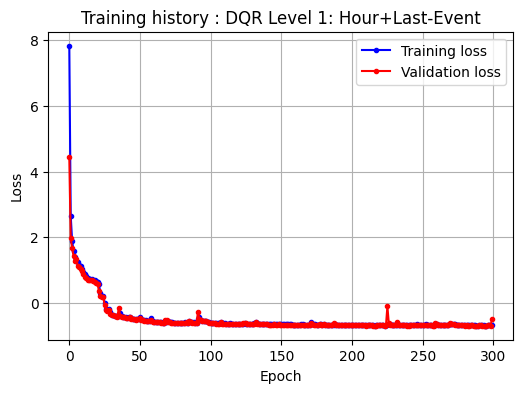

In [26]:
model_level_1 = get_or_train_model(
    f"models/{ticker}/dqr_level_1.pt",
    data=df_train_1,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[1]["hour_last_event"].nunique())
model_level_1.plot_history(model_name="Level 1: Hour+Last-Event")

In [27]:
model_level_2 = get_or_train_model(
    f"models/{ticker}/dqr_level_2.pt",
    data=df_train_2,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[2]["hour_last_event"].nunique())

In [28]:
model_level_3 = get_or_train_model(
    f"models/{ticker}/dqr_level_3.pt",
    data=df_train_3,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[3]["hour_last_event"].nunique())

In [29]:
model_level_4 = get_or_train_model(
    f"models/{ticker}/dqr_level_4.pt",
    data=df_train_4,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[4]["hour_last_event"].nunique())

In [30]:
model_level_5 = get_or_train_model(
    f"models/{ticker}/dqr_level_5.pt",
    data=df_train_5,
    compute_model=False,
    use_hour=True,
    use_last_event=True,
    hour_num_classes=dfs_by_abs_level[5]["hour_last_event"].nunique())

### Simulation of LOB ###

In [47]:
Q_MAX = 500
TICK_SIZE = 50
MARKET_OPEN_S = 34200  # 9:30:00 par exemple


def get_hour_id(abs_time_s, t_start=MARKET_OPEN_S, max_hour_id=6):
    return min(int((t_start + abs_time_s) // 3600) - int(t_start // 3600), max_hour_id)


def model_intensities(model, q_val, last_event, hour_id, device="cpu"):
    model.eval()
    with torch.no_grad():
        x_q = torch.tensor([q_val], dtype=torch.float32, device=device)
        x_last = torch.tensor([last_event], dtype=torch.long, device=device)
        x_hour = torch.tensor([hour_id], dtype=torch.long, device=device)

        # ordre correct : (q, last_event, hour)
        out = model(x_q, x_last, x_hour)

        if out.dim() == 2:
            out = out[0]

        lam = out.detach().cpu().numpy().astype(float)

    lam = np.clip(lam, 1e-12, None)
    return lam


def compute_book_snapshot(pref, qa, qb, K=5, tick_size=50):
    """
    Construit un dictionnaire avec colonnes type:
    P_1, Q_1, ..., P_5, Q_5, P_-1, Q_-1, ..., P_-5, Q_-5
    """
    snap = {"pref": pref}

    for l in range(1, K + 1):
        snap[f"P_{l}"] = pref + l * tick_size
        snap[f"Q_{l}"] = int(qa[l - 1])

    for l in range(1, K + 1):
        snap[f"P_-{l}"] = pref - l * tick_size
        snap[f"Q_-{l}"] = int(qb[l - 1])

    return snap


def shift_book_after_ask_depletion(qa, qb, last_ask, last_bid, refill_ask=1, refill_bid=1):
    """
    qa[0] vidé -> le prix monte.
    On décale les niveaux.
    """
    qa = np.roll(qa, -1)
    qa[-1] = refill_ask

    qb = np.roll(qb, 1)
    qb[0] = refill_bid

    last_ask = np.roll(last_ask, -1)
    last_ask[-1] = 0

    last_bid = np.roll(last_bid, 1)
    last_bid[0] = 0

    return qa, qb, last_ask, last_bid


def shift_book_after_bid_depletion(qa, qb, last_ask, last_bid, refill_ask=1, refill_bid=1):
    """
    qb[0] vidé -> le prix baisse.
    On décale les niveaux.
    """
    qb = np.roll(qb, -1)
    qb[-1] = refill_bid

    qa = np.roll(qa, 1)
    qa[0] = refill_ask

    last_bid = np.roll(last_bid, -1)
    last_bid[-1] = 0

    last_ask = np.roll(last_ask, 1)
    last_ask[0] = 0

    return qa, qb, last_ask, last_bid

def build_empirical_size_sampler(df_norm, K=5):
    samplers = {}
    for lvl in range(-K, K + 1):
        if lvl == 0:
            continue
        for typ in ["L", "C", "M"]:
            arr = df_norm[(df_norm["lvl"] == lvl) & (df_norm["type"] == typ)]["size"].dropna().values
            if len(arr) == 0:
                arr = np.array([1.0])
            samplers[(lvl, typ)] = arr.astype(float)
    return samplers


def simulate_dqr_day(
    models_by_level,
    init_qa,
    init_qb,
    K=5,
    T_sim=23400.0,
    t_start=MARKET_OPEN_S,
    pref0=275150.0,
    tick_size=TICK_SIZE,
    q_max=Q_MAX,
    max_events=2_000_000,
    device="cpu",
    refill_mode="constant",
    refill_value=1,
    empirical_q_ask=None,
    empirical_q_bid=None,
    empirical_size_sampler=None
):
    """
    models_by_level: dict ou liste indexée par niveau absolu
        ex: {1: model_level_1, ..., 5: model_level_5}

    init_qa, init_qb: tailles initiales ask/bid de longueur K
    """

    qa = np.array(init_qa, dtype=float).copy()
    qb = np.array(init_qb, dtype=float).copy()

    last_ask = np.zeros(K, dtype=int)
    last_bid = np.zeros(K, dtype=int)

    pref = float(pref0)
    t = 0.0
    seg_id = 1
    dt_since_seg_start = 0.0

    rows = []

    for _ in range(max_events):
        if t >= T_sim:
            break

        hour_id = get_hour_id(t, t_start=t_start)

        # 1) Construire toutes les intensités élémentaires
        # événements = (side, level_abs, event_type, intensity)
        # side = +1 ask, -1 bid
        event_list = []

        for l in range(1, K + 1):
            model = models_by_level[l]

            lam_ask = model_intensities(
                model=model,
                q_val=float(qa[l - 1]),
                last_event=int(last_ask[l - 1]),
                hour_id=int(hour_id),
                device=device,
            )

            lam_bid = model_intensities(
                model=model,
                q_val=float(qb[l - 1]),
                last_event=int(last_bid[l - 1]),
                hour_id=int(hour_id),
                device=device,
            )

            # sécurité: si queue vide, pas de cancel/market possibles
            if qa[l - 1] <= 0:
                lam_ask[1:] = 0.0
            if qb[l - 1] <= 0:
                lam_bid[1:] = 0.0

            # market order uniquement au niveau 1
            if l > 1 and len(lam_ask) >= 3:
                lam_ask[2] = 0.0
                lam_bid[2] = 0.0

            # side = +1 ask, -1 bid
            for ev_type in range(len(lam_ask)):
                event_list.append((+1, l, ev_type, lam_ask[ev_type]))
            for ev_type in range(len(lam_bid)):
                event_list.append((-1, l, ev_type, lam_bid[ev_type]))

        lambdas = np.array([x[3] for x in event_list], dtype=float)
        Lambda = lambdas.sum()

        if Lambda <= 0:
            break

        # 2) Tirage du prochain temps
        dt = np.random.exponential(scale=1.0 / Lambda)
        t += dt
        if t > T_sim:
            break

        dt_since_seg_start += dt

        # 3) Tirage du type d'événement
        idx = np.random.choice(len(event_list), p=lambdas / Lambda)
        side, level_abs, ev_type, _ = event_list[idx]

        # conventions
        # ev_type: 0=L, 1=C, 2=M
        type_str = {0: "L", 1: "C", 2: "M"}[ev_type]
        signed_lvl = level_abs if side == +1 else -level_abs
        if empirical_size_sampler is not None:
            pool = empirical_size_sampler.get((signed_lvl, type_str), np.array([1.0]))
            size = float(np.random.choice(pool))
        else:
            size = 1.0

        # 4) Mise à jour du carnet
        price_moved = False

        if side == +1:
            i = level_abs - 1
            if ev_type == 0:
                qa[i] = min(qa[i] + size, q_max)
                last_ask[i] = ev_type
            elif ev_type in [1, 2]:
                if qa[i] > 0:
                    qa[i] = max(qa[i] - size, 0.0)
                    last_ask[i] = ev_type
        else:
            i = level_abs - 1
            if ev_type == 0:
                qb[i] = min(qb[i] + size, q_max)
                last_bid[i] = ev_type
            elif ev_type in [1, 2]:
                if qb[i] > 0:
                    qb[i] = max(qb[i] - size, 0.0)
                    last_bid[i] = ev_type

        # 5) Gestion des mouvements de prix
        while qa[0] <= 0:
            price_moved = True
            pref += tick_size

            if refill_mode == "empirical" and empirical_q_ask is not None and empirical_q_bid is not None:
                refill_ask = float(np.random.choice(empirical_q_ask))
                refill_bid = float(np.random.choice(empirical_q_bid))
            else:
                refill_ask = refill_value
                refill_bid = refill_value

            qa, qb, last_ask, last_bid = shift_book_after_ask_depletion(
                qa, qb, last_ask, last_bid,
                refill_ask=refill_ask,
                refill_bid=refill_bid
            )

            seg_id += 1
            dt_since_seg_start = 0.0

        while qb[0] <= 0:
            price_moved = True
            pref -= tick_size

            if refill_mode == "empirical" and empirical_q_ask is not None and empirical_q_bid is not None:
                refill_ask = float(np.random.choice(empirical_q_ask))
                refill_bid = float(np.random.choice(empirical_q_bid))
            else:
                refill_ask = refill_value
                refill_bid = refill_value

            qa, qb, last_ask, last_bid = shift_book_after_bid_depletion(
                qa, qb, last_ask, last_bid,
                refill_ask=refill_ask,
                refill_bid=refill_bid
            )

            seg_id += 1
            dt_since_seg_start = 0.0

        # 6) Snapshot
        row = {
            "time": t_start + t,
            "dtk": dt,
            "dtk_l": dt_since_seg_start,
            "type": type_str,
            "price": pref + signed_lvl * tick_size,
            "lvl": signed_lvl,
            "size": size,
            "pref": pref,
            "hour_id": hour_id,
            "seg_id": seg_id,
        }

        row.update(compute_book_snapshot(pref, qa, qb, K=K, tick_size=tick_size))
        rows.append(row)

    df_sim = pd.DataFrame(rows)
    return df_sim

In [48]:
print(model_level_1(
    torch.tensor([10.0], dtype=torch.float32),
    torch.tensor([0], dtype=torch.long),
    torch.tensor([0], dtype=torch.long)
))

tensor([[6.4722, 4.8883, 0.1581]], grad_fn=<ReluBackward0>)


In [50]:
models_by_level = {
    1: model_level_1,
    2: model_level_2,
    3: model_level_3,
    4: model_level_4,
    5: model_level_5,
}

init_qa = [10, 12, 15, 18, 20]
init_qb = [11, 13, 14, 17, 21]

empirical_q_ask = df_norm["Q_5"].dropna().values.astype(float)
empirical_q_bid = df_norm["Q_-5"].dropna().values.astype(float)

size_sampler = build_empirical_size_sampler(df_norm, K=5)

df_sim = simulate_dqr_day(
    models_by_level=models_by_level,
    init_qa=init_qa,
    init_qb=init_qb,
    K=5,
    T_sim=3600.0,
    t_start=34200.0,
    pref0=275150.0,
    tick_size=50,
    q_max=500,
    device="cpu",
    refill_mode="empirical",   # ou "empirical"
    empirical_q_ask=empirical_q_ask,
    empirical_q_bid=empirical_q_bid,
    empirical_size_sampler=size_sampler
)

df_sim

,time,dtk,dtk_l,type,price,lvl,size,pref,hour_id,seg_id,...,P_-1,Q_-1,P_-2,Q_-2,P_-3,Q_-3,P_-4,Q_-4,P_-5,Q_-5
0,34200.005198,0.005198,0.005198,L,275050.0,-2,1.0,275150.0,0,1,...,275100.0,11,275050.0,14,275000.0,14,274950.0,17,274900.0,21
1,34200.006688,0.001490,0.006688,L,275050.0,-2,1.0,275150.0,0,1,...,275100.0,11,275050.0,15,275000.0,14,274950.0,17,274900.0,21
2,34200.012126,0.005438,0.012126,C,275250.0,2,13.0,275150.0,0,1,...,275100.0,11,275050.0,15,275000.0,14,274950.0,17,274900.0,21
3,34200.019131,0.007004,0.019131,C,275350.0,4,2.0,275150.0,0,1,...,275100.0,11,275050.0,15,275000.0,14,274950.0,17,274900.0,21
4,34200.019795,0.000664,0.019795,C,275100.0,-1,1.0,275150.0,0,1,...,275100.0,10,275050.0,15,275000.0,14,274950.0,17,274900.0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138756,37799.887610,0.010494,3580.297894,C,274950.0,-1,3.0,275000.0,1,4,...,274950.0,483,274900.0,0,274850.0,24,274800.0,41,274750.0,39
138757,37799.900668,0.013058,3580.310953,C,274950.0,-1,3.0,275000.0,1,4,...,274950.0,480,274900.0,0,274850.0,24,274800.0,41,274750.0,39
138758,37799.921081,0.020413,3580.331366,C,274950.0,-1,1.0,275000.0,1,4,...,274950.0,479,274900.0,0,274850.0,24,274800.0,41,274750.0,39
138759,37799.939021,0.017940,3580.349306,L,275050.0,1,2.0,275000.0,1,4,...,274950.0,479,274900.0,0,274850.0,24,274800.0,41,274750.0,39


In [51]:
df.to_parquet("dqr_simulation_intc.parquet")

In [52]:
df_norm[df_norm["time"]<37800]

,time,dtk,dtk_l,type,price,lvl,size,pref,P_1,Q_1,...,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5,seg_id
0,34200.006241,0.006241,0.006241,L,275200,1,1,275150.0,275200.0,1,...,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1,1
1,34200.006462,0.000221,0.000221,L,275500,4,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
2,34200.048864,0.042402,0.042623,C,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
3,34200.048883,0.000020,0.042642,C,275100,-1,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
4,34200.048989,0.000106,0.000125,L,275000,-2,1,275150.0,275200.0,1,...,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127205,37799.784700,0.000032,2.703629,C,273000,-5,1,273450.0,273500.0,9,...,34,273800.0,32,273100.0,30,273900.0,20,273000.0,26,474
127206,37799.784794,0.000094,9.841103,L,273800,4,1,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,20,273000.0,26,474
127207,37799.784977,0.000184,9.216664,L,273900,5,3,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,22,273000.0,26,474
127208,37799.881033,0.096056,0.096365,C,273400,-1,2,273450.0,273500.0,9,...,34,273800.0,33,273100.0,30,273900.0,22,273000.0,26,474


In [53]:
def empirical_intensity(df, level):
    sub = df[np.abs(df["lvl"]) == level]
    T = df["time"].max() - df["time"].min()
    
    return {
        "L": (sub["type"] == "L").sum() / T,
        "C": (sub["type"] == "C").sum() / T,
        "M": (sub["type"] == "M").sum() / T,
    }

for l in range(1, 6):
    print(f"\nLevel {l}")
    print("sim:", empirical_intensity(df_sim, l))
    print("real:", empirical_intensity(df_norm, l))


Level 1
sim: {'L': np.float64(16.661065764876163), 'C': np.float64(13.420742782711065), 'M': np.float64(0.15389103575820529)}
real: {'L': np.float64(8.427114832566797), 'C': np.float64(6.941000050664152), 'M': np.float64(1.3881230868659022)}

Level 2
sim: {'L': np.float64(1.7430798725320182), 'C': np.float64(1.96808301145647), 'M': np.float64(0.0)}
real: {'L': np.float64(1.717824755949408), 'C': np.float64(2.553553315974948), 'M': np.float64(0.0)}

Level 3
sim: {'L': np.float64(1.131126890988108), 'C': np.float64(1.09779309262893), 'M': np.float64(0.0)}
real: {'L': np.float64(0.9703870122980125), 'C': np.float64(0.9635921237193634), 'M': np.float64(0.0)}

Level 4
sim: {'L': np.float64(0.6461201248620676), 'C': np.float64(0.6405644918022046), 'M': np.float64(0.0)}
real: {'L': np.float64(0.5654287470698465), 'C': np.float64(0.5079072374669431), 'M': np.float64(0.0)}

Level 5
sim: {'L': np.float64(0.5352852453178006), 'C': np.float64(0.5475076380494993), 'M': np.float64(0.0)}
real: {'L':

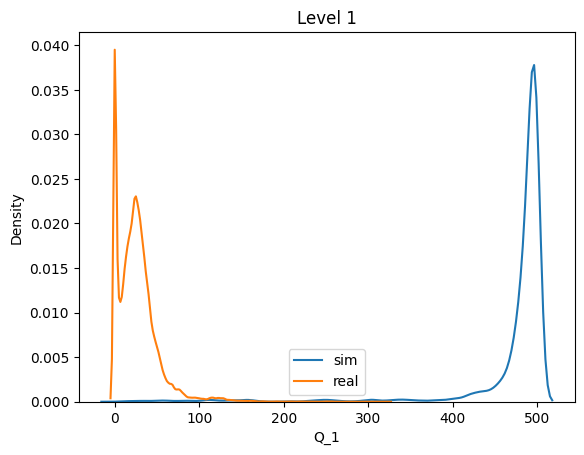

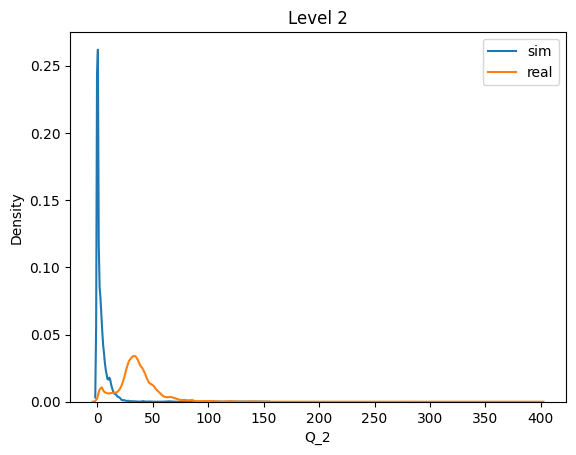

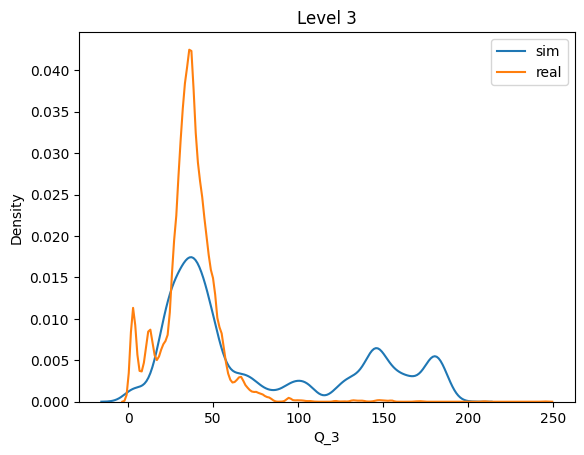

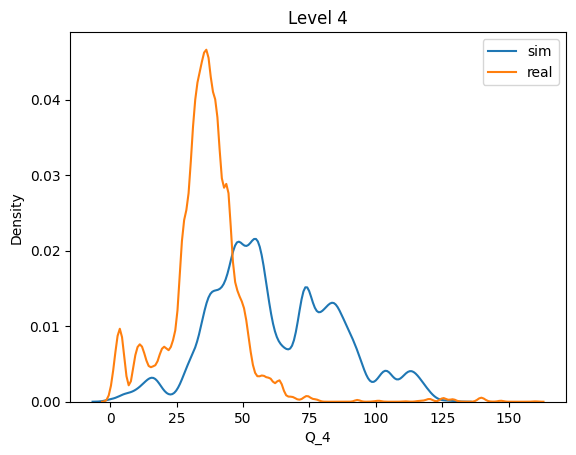

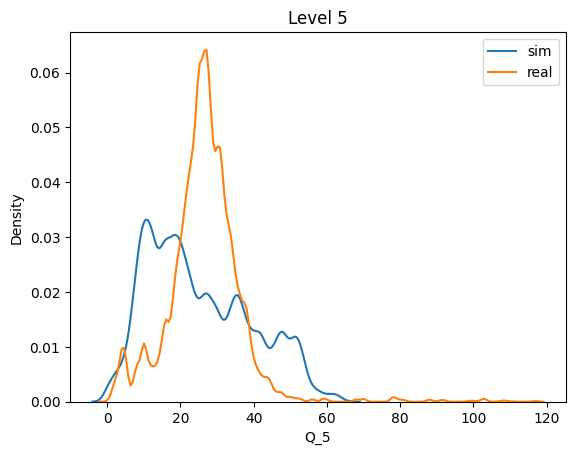

In [54]:
import seaborn as sns

for l in range(1, 6):
    col = f"Q_{l}"
    
    sns.kdeplot(df_sim[col], label="sim")
    sns.kdeplot(df_norm[col], label="real")
    
    plt.title(f"Level {l}")
    plt.legend()
    plt.show()

In [55]:
def conditional_event_rate(df, level):
    sub = df[np.abs(df["lvl"]) == level]
    
    bins = [0,2,5,10,20,50,100]
    
    for i in range(len(bins)-1):
        bmin, bmax = bins[i], bins[i+1]
        
        cond = (sub[f"Q_{level}"] >= bmin) & (sub[f"Q_{level}"] < bmax)
        sub_bin = sub[cond]
        
        if len(sub_bin) == 0:
            continue
        
        rate_L = (sub_bin["type"] == "L").mean()
        rate_C = (sub_bin["type"] == "C").mean()
        rate_M = (sub_bin["type"] == "M").mean()
        
        print(f"{bmin}-{bmax}: L={rate_L:.2f}, C={rate_C:.2f}, M={rate_M:.2f}")

In [56]:
print("Simulation")
conditional_event_rate(df_sim, level=1)
print("REal")
conditional_event_rate(df_norm, level=1)

Simulation
2-5: L=0.00, C=0.00, M=1.00
5-10: L=0.17, C=0.33, M=0.50
10-20: L=0.41, C=0.44, M=0.15
20-50: L=0.52, C=0.47, M=0.01
50-100: L=0.55, C=0.44, M=0.01
REal
0-2: L=0.52, C=0.44, M=0.04
2-5: L=0.45, C=0.32, M=0.23
5-10: L=0.48, C=0.37, M=0.15
10-20: L=0.50, C=0.42, M=0.08
20-50: L=0.51, C=0.42, M=0.08
50-100: L=0.50, C=0.40, M=0.10


In [57]:
lam_L, lam_C, lam_M = [], [], []

for _ in range(10000):
    l = model_intensities(model_level_1, q_val=10, last_event=0, hour_id=0)
    lam_L.append(l[0])
    lam_C.append(l[1])
    lam_M.append(l[2])

print(np.mean(lam_L), np.mean(lam_C), np.mean(lam_M))

6.472157955169678 4.88830041885376 0.15807905793190002


<Axes: >

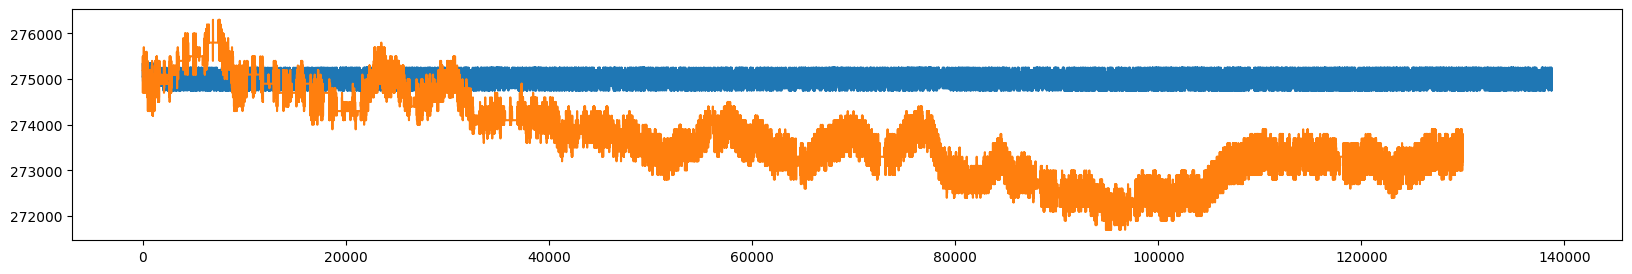

In [58]:
df_sim["price"].plot(figsize=(20, 3))
df_norm[:130000]["price"].plot(figsize=(20, 3))

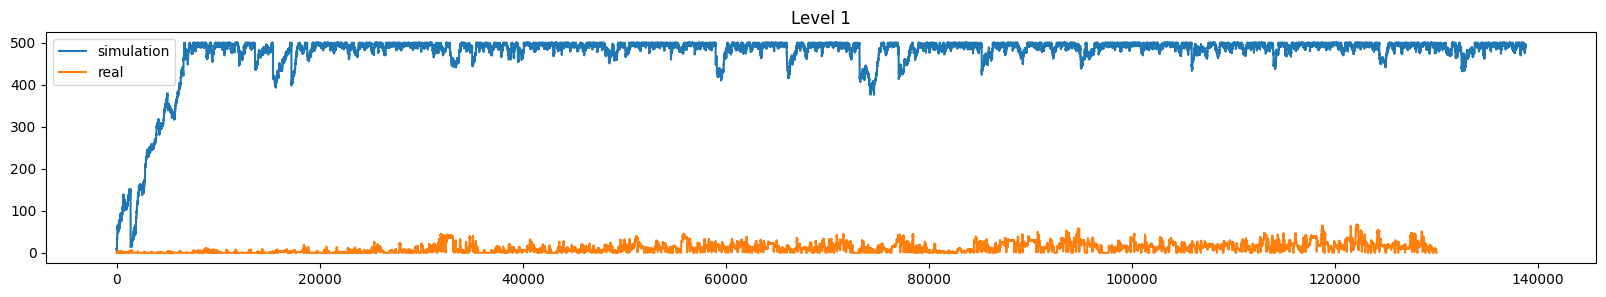

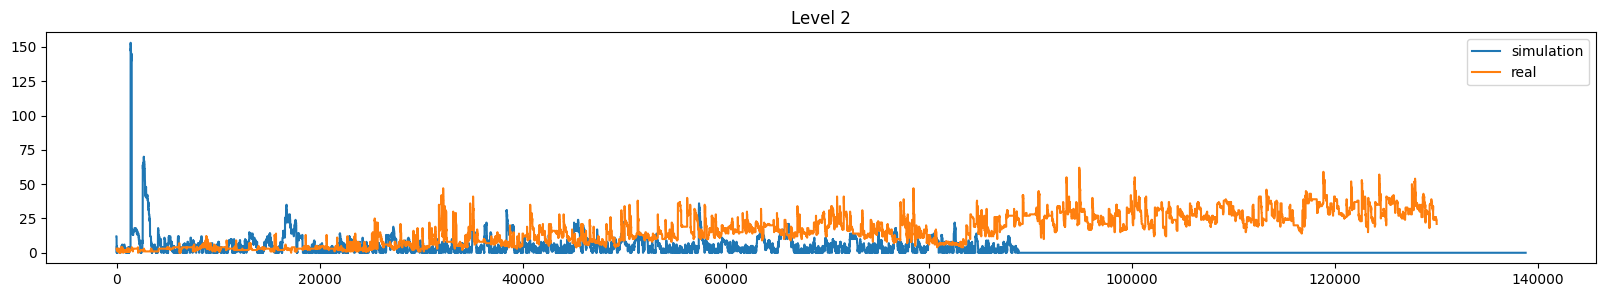

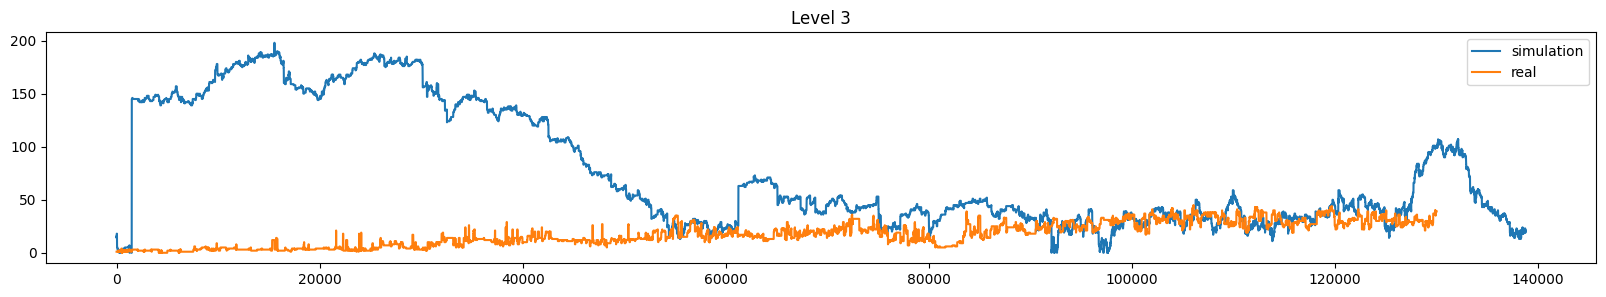

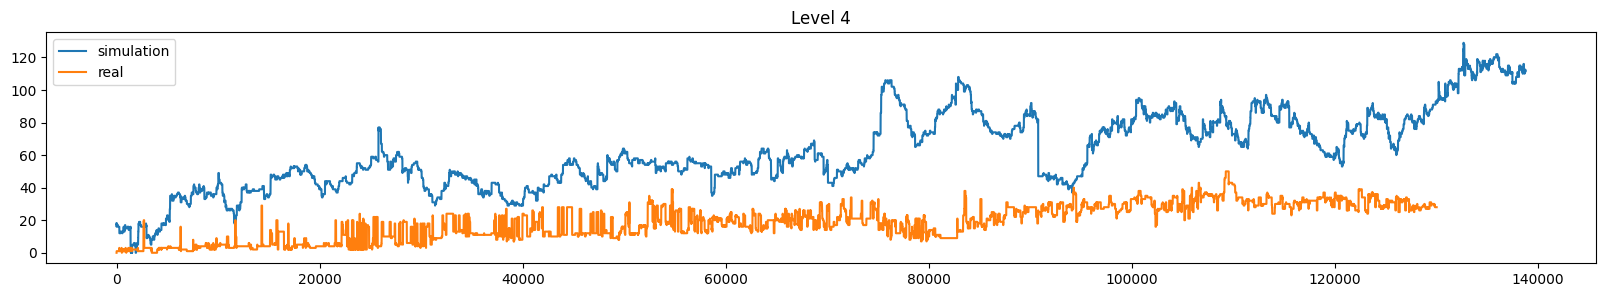

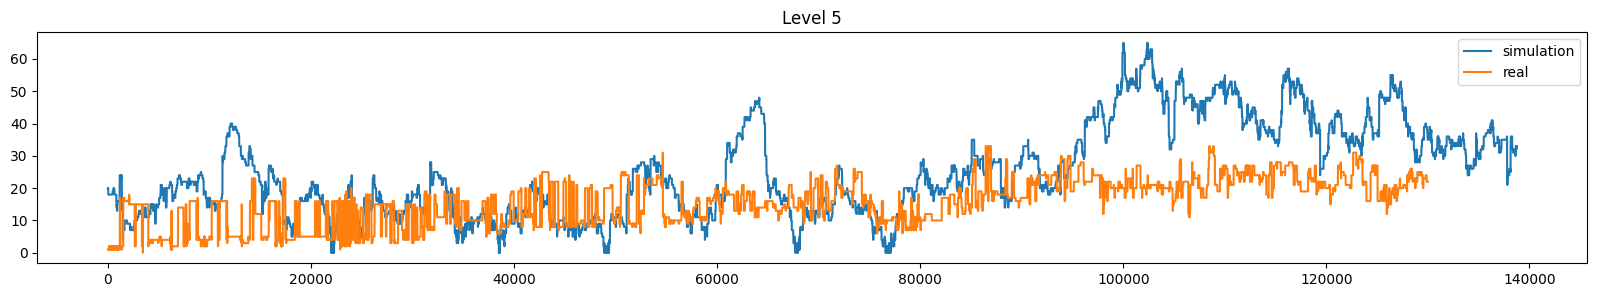

In [59]:
for i in range(1,6):
    plt.figure(figsize=(20, 3))
    df_sim[f"Q_{i}"].plot(figsize=(20, 3), label="simulation")
    df_norm[f"Q_{i}"][:130000].plot(figsize=(20, 3), label="real")
    plt.legend()
    plt.title(f"Level {i}")